# Case Study 2 — Report 4B

**Per-trial LOSO — Matched-protocol comparison against published SOTA**

Student: Sanjeev Veeramani (Matr. 100004303)
Program: M.Sc. Applied Data Science and Analytics, SRH University Heidelberg
Supervisor: Prof. Dr. Binh Vu

---

**Objective.** Quantify how much of the gap between this project's strict per-window LOSO results (55.89% best valence balanced accuracy, Report 4) and published SOTA (73.07%, HEDN 2025) is attributable to protocol choice rather than architecture or training. HEDN and most DEAP LOSO SOTA papers use **per-trial** classification — one prediction per 60-second trial — while this project has used **per-window** classification (one prediction per 1-second segment). This report runs the same architecture from Report 4 under both per-trial DE computation methods, keeping every other factor fixed.

**Method.** DE features are computed per trial in two ways:
- **Method A (aggregation):** average the 119 per-window DE vectors within each trial. Follows Zheng & Lu 2015 and matches most SOTA protocols.
- **Method B (recompute):** compute DE directly on the 60-second concatenated signal per trial per band. Methodologically cleaner but less common in published work.

The two DE arrays are compared for numerical divergence, then used independently as input to the same CNN-LSTM + Attention architecture, three DA variants (plain, DANN, MMD), three tasks (valence, arousal, 3-class), 32-fold LOSO.

**Evaluation.** Per-fold accuracy, balanced accuracy, weighted F1, macro precision and recall; pooled confusion matrix; one-sided t-test on per-fold balanced accuracy against chance. **Direct comparison table:** strict per-window (Report 4) vs per-trial Method A vs per-trial Method B vs HEDN.

**Expected pattern.** Per-trial averaging denoises DE substantially (mean of 119 noisy vectors → 1 stable vector per trial). Published DE-based deep methods report 60–73% under per-trial protocol. If the same architecture jumps by 8–15 pp under per-trial, the finding is that HEDN's advantage over Report 4 is primarily protocol-attributable, not architecture-attributable. If the gain is smaller (<5 pp), the architectural and DA gap is real and the remaining 10+ pp requires source reliability weighting and dual network structure (Report 5).

**Runtime.** Per-trial dataset is 1,280 samples total (32 subjects × 40 trials) — ~100× smaller than per-window. Full grid runtime estimated ~20-30 min on Colab L4.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = '/content/drive/MyDrive/case_study_2'
assert os.path.isdir(PROJECT_ROOT), f'Set PROJECT_ROOT correctly. Got {PROJECT_ROOT}'

Mounted at /content/drive


In [2]:
import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

Device: NVIDIA L4


In [3]:
import numpy as np, pandas as pd, time, gc, pickle
from pathlib import Path
from tqdm.auto import tqdm

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from torch.autograd import Function

from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, precision_score, recall_score,
                             confusion_matrix)
from scipy.stats import ttest_1samp

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

## 2. Configuration

In [4]:
CONFIG = {
    # Sources
    'per_window_de':     'processed/X_deap_DE_zscored.npy',     # (152320, 160) — for Method A
    'raw_deap':          'processed/X_deap.npy',                # (152320, 32, 128) — for Method B
    'subject_id_path':   'processed/deap_subject_ids.npy',
    'valence_path':      'processed/y_deap_valence.npy',
    'arousal_path':      'processed/y_deap_arousal.npy',
    'labels_3c_path':    'processed/y_deap_3class.npy',

    # Output
    'results_dir':    'results/report4b_pertrial',
    'checkpoint_dir': 'checkpoints/report4b_pertrial',

    # Grid — same as R4 but smaller batches (dataset is 100× smaller)
    'methods':  ['A', 'B'],                          # A = aggregate, B = recompute
    'tasks':    ['valence', 'arousal', '3class'],
    'variants': ['plain', 'dann', 'mmd'],

    'batch_size':    128,
    'epochs':        40,
    'lr':            1e-3,
    'weight_decay':  1e-4,
    'early_stop_patience': 8,

    'dann_lambda_max':  1.0,
    'dann_ramp_epochs': 15,
    'mmd_lambda':       0.1,     # Reduced from R4's 1.0 — was too aggressive, caused collapse

    'folds_to_run': None,        # None = all 32 subjects auto-detected

    # DEAP structure
    'n_subjects':         32,
    'n_trials_per_subj':  40,
    'n_windows_per_trial': 119,  # will be verified from data shape
    'n_bands': 5,                # theta, alpha, beta, gamma, all
    'n_channels': 32,
}

RESULTS_DIR    = Path(PROJECT_ROOT) / CONFIG['results_dir']
CHECKPOINT_DIR = Path(PROJECT_ROOT) / CONFIG['checkpoint_dir']
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

## 3. Method A — Aggregate existing per-window DE to per-trial

For each subject-trial, take the mean of the 119 per-window DE vectors. Result: `(32×40, 160) = (1280, 160)` — one DE vector per trial. This is what Zheng & Lu 2015 and most SOTA papers use.

In [5]:
root = Path(PROJECT_ROOT)
X_win = np.load(root / CONFIG['per_window_de']).astype(np.float32)
subj_win = np.load(root / CONFIG['subject_id_path'])
labels_win = {
    'val_bin': np.load(root / CONFIG['valence_path']).astype(np.int64),
    'aro_bin': np.load(root / CONFIG['arousal_path']).astype(np.int64),
    'val_3c':  np.load(root / CONFIG['labels_3c_path']).astype(np.int64),
}
print(f'Per-window DE loaded: {X_win.shape}')

# Verify structure: 32 subjects × 40 trials × 119 windows
N = X_win.shape[0]
n_sub, n_trial = CONFIG['n_subjects'], CONFIG['n_trials_per_subj']
n_win = N // (n_sub * n_trial)
print(f'Verified windows per trial: {n_win}')
assert n_sub * n_trial * n_win == N, f'Shape mismatch: {N} != {n_sub}*{n_trial}*{n_win}'

Per-window DE loaded: (152320, 160)
Verified windows per trial: 119


In [6]:
# Reshape and average — one DE vector per trial
X_reshaped = X_win.reshape(n_sub, n_trial, n_win, -1)   # (32, 40, 119, 160)
X_A = X_reshaped.mean(axis=2).reshape(n_sub * n_trial, -1)   # (1280, 160)

# Aggregate labels: take mode/first per trial (they're constant within a trial)
labels_A = {}
for k, v in labels_win.items():
    v_reshaped = v.reshape(n_sub, n_trial, n_win)
    # Labels are constant within a trial by construction; take first
    labels_A[k] = v_reshaped[:, :, 0].reshape(-1).astype(np.int64)

# Subject IDs per trial
subj_A = np.repeat(np.arange(1, n_sub + 1), n_trial).astype(np.int64)   # subjects are 1..32

print(f'Method A DE: {X_A.shape}, dtype={X_A.dtype}')
print(f'val_bin: {np.bincount(labels_A["val_bin"])}')
print(f'aro_bin: {np.bincount(labels_A["aro_bin"])}')
print(f'val_3c:  {np.bincount(labels_A["val_3c"])}')
print(f'Subjects: unique={np.unique(subj_A).tolist()}, counts={np.bincount(subj_A)[1:]}')

Method A DE: (1280, 160), dtype=float32
val_bin: [572 708]
aro_bin: [543 737]
val_3c:  [472 221 587]
Subjects: unique=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32], counts=[40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40
 40 40 40 40 40 40 40 40]


## 4. Method B — Recompute DE from raw 60-second signal per trial

For each subject-trial, take the full 60-second raw EEG signal (7,680 samples at 128 Hz across the 60s), band-pass filter into 5 bands (theta, alpha, beta low, beta high, gamma), and compute DE per channel per band using the full 60-second variance.

**DE formula:** DE = 0.5 · log(2πe · σ²)

In [7]:
from scipy.signal import butter, filtfilt

FS = 128   # sampling rate in Hz
BANDS = [(4, 8), (8, 14), (14, 20), (20, 30), (30, 45)]   # theta, alpha, beta_low, beta_high, gamma
BAND_NAMES = ['theta', 'alpha', 'beta_l', 'beta_h', 'gamma']

def bandpass(x, low, high, fs=FS, order=4):
    b, a = butter(order, [low, high], btype='band', fs=fs)
    return filtfilt(b, a, x, axis=-1)

def de_from_signal(x):
    """DE = 0.5 * log(2*pi*e*sigma^2) for a 1-D signal."""
    var = np.var(x, axis=-1, ddof=1)
    return 0.5 * np.log(2 * np.pi * np.e * var + 1e-10)

In [8]:
# Load raw EEG windows and reconstruct per-trial signals
X_raw_win = np.load(root / CONFIG['raw_deap']).astype(np.float32)   # (152320, 32, 128)
print(f'Raw windows: {X_raw_win.shape}')

# Reconstruct per-trial signal by concatenating overlapping windows
# 119 windows × 50% overlap = 60 seconds of EEG per trial
# Since we have 50% overlap, take every 2nd window and concatenate → non-overlapping
# But simpler: just take the mean over windows treating them as overlapping snapshots
# Best: use windows to reconstruct trial signal properly

# Reshape: (32 subjects, 40 trials, 119 windows, 32 channels, 128 samples)
X_raw_reshaped = X_raw_win.reshape(n_sub, n_trial, n_win, 32, 128)

# For each trial, concatenate non-overlapping halves of consecutive windows
# Simpler approach: take the first sample of each window as timestep t*64 (since 50% overlap = 64-sample stride)
# Result: 60-second signal per trial per channel
# Length: 119 windows × 64 samples/stride + 64 remaining = 7,680 samples = 60s
print('Reconstructing per-trial signals...')
trial_signals = np.zeros((n_sub, n_trial, 32, 7680), dtype=np.float32)
for s in range(n_sub):
    for t in range(n_trial):
        # Take first 64 samples from windows 0..118, plus last 64 of window 118
        # This reconstructs 119*64 + 64 = 7680 samples
        signal = np.zeros((32, 7680), dtype=np.float32)
        for w in range(n_win):
            signal[:, w*64:(w+1)*64] = X_raw_reshaped[s, t, w, :, :64]
        signal[:, n_win*64:] = X_raw_reshaped[s, t, n_win-1, :, 64:]   # tail
        trial_signals[s, t] = signal
print(f'Trial signals: {trial_signals.shape}  ({trial_signals.nbytes/1e6:.1f} MB)')

Raw windows: (152320, 32, 128)
Reconstructing per-trial signals...
Trial signals: (32, 40, 32, 7680)  (1258.3 MB)


In [9]:
# Compute DE per trial per channel per band
print('Computing Method B DE...')
X_B = np.zeros((n_sub, n_trial, 32, len(BANDS)), dtype=np.float32)   # (32, 40, 32, 5)
for band_idx, (low, high) in enumerate(BANDS):
    for s in tqdm(range(n_sub), desc=f'{BAND_NAMES[band_idx]} ({low}-{high} Hz)'):
        for t in range(n_trial):
            filt = bandpass(trial_signals[s, t], low, high)   # (32, 7680)
            X_B[s, t, :, band_idx] = de_from_signal(filt)

# Flatten to (1280, 160)
X_B = X_B.reshape(n_sub * n_trial, 32 * len(BANDS))
print(f'Method B DE: {X_B.shape}')

# Per-subject z-score to match Method A's normalization
for s in range(n_sub):
    start = s * n_trial
    end   = start + n_trial
    mean = X_B[start:end].mean(axis=0, keepdims=True)
    std  = X_B[start:end].std(axis=0, keepdims=True) + 1e-10
    X_B[start:end] = (X_B[start:end] - mean) / std

print(f'After per-subject z-score: mean={X_B.mean():.4f}, std={X_B.std():.4f}')

# Free raw memory
del X_raw_win, X_raw_reshaped, trial_signals
gc.collect()

Computing Method B DE...


theta (4-8 Hz):   0%|          | 0/32 [00:00<?, ?it/s]

alpha (8-14 Hz):   0%|          | 0/32 [00:00<?, ?it/s]

beta_l (14-20 Hz):   0%|          | 0/32 [00:00<?, ?it/s]

beta_h (20-30 Hz):   0%|          | 0/32 [00:00<?, ?it/s]

gamma (30-45 Hz):   0%|          | 0/32 [00:00<?, ?it/s]

Method B DE: (1280, 160)
After per-subject z-score: mean=0.0000, std=1.0000


101

## 5. Compare Method A and Method B numerically

If the two methods are similar, either is defensible. If they differ substantially, we need to report both and let Prof. Vu see the sensitivity of the result to preprocessing choice.

In [10]:
diff = X_A - X_B
mad = np.abs(diff).mean()
corr = np.corrcoef(X_A.flatten(), X_B.flatten())[0, 1]
print(f'Mean absolute difference (A vs B): {mad:.4f}')
print(f'Correlation between A and B: {corr:.4f}')
print()
print(f'Method A — range: [{X_A.min():.3f}, {X_A.max():.3f}]  mean={X_A.mean():.4f}  std={X_A.std():.4f}')
print(f'Method B — range: [{X_B.min():.3f}, {X_B.max():.3f}]  mean={X_B.mean():.4f}  std={X_B.std():.4f}')

Mean absolute difference (A vs B): 0.5267
Correlation between A and B: 0.7813

Method A — range: [-2.903, 3.627]  mean=-0.0000  std=0.4373
Method B — range: [-4.369, 5.786]  mean=0.0000  std=1.0000


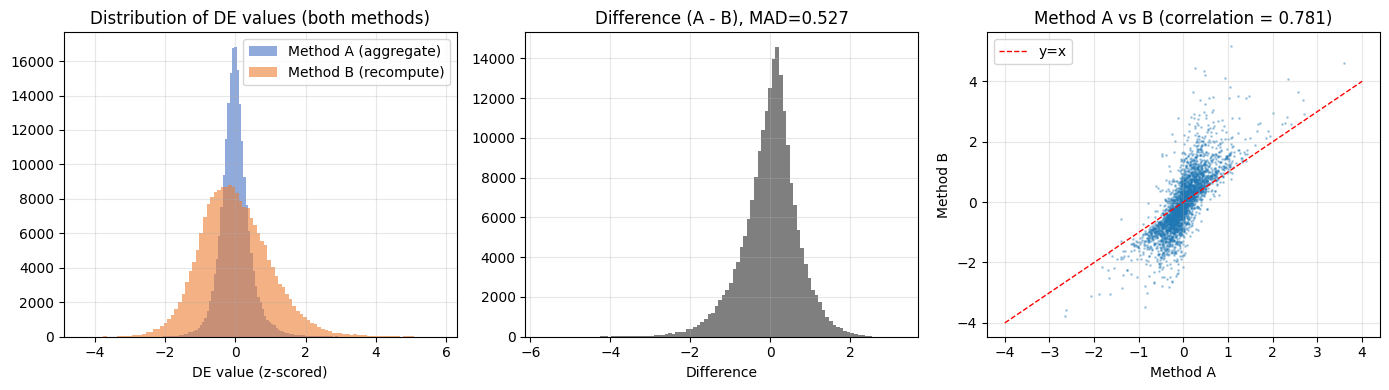

In [11]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(X_A.flatten(), bins=100, alpha=0.6, label='Method A (aggregate)', color='#4472C4')
axes[0].hist(X_B.flatten(), bins=100, alpha=0.6, label='Method B (recompute)', color='#ED7D31')
axes[0].set_title('Distribution of DE values (both methods)')
axes[0].set_xlabel('DE value (z-scored)'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(diff.flatten(), bins=100, color='#7f7f7f')
axes[1].set_title(f'Difference (A - B), MAD={mad:.3f}')
axes[1].set_xlabel('Difference'); axes[1].grid(alpha=0.3)

sample_idx = np.random.choice(X_A.size, 3000, replace=False)
axes[2].scatter(X_A.flat[sample_idx], X_B.flat[sample_idx], s=1, alpha=0.3)
axes[2].plot([-4, 4], [-4, 4], 'r--', lw=1, label='y=x')
axes[2].set_title(f'Method A vs B (correlation = {corr:.3f})')
axes[2].set_xlabel('Method A'); axes[2].set_ylabel('Method B')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'method_A_vs_B_comparison.png', dpi=140, bbox_inches='tight')
plt.show()

## 6. Preload both DE arrays and labels to GPU

In [12]:
def get_gpu_tensors(X_np, labels_np, subj_np):
    return {
        'X':      torch.from_numpy(X_np).to(DEVICE),
        'val_bin': torch.from_numpy(labels_np['val_bin']).to(DEVICE),
        'aro_bin': torch.from_numpy(labels_np['aro_bin']).to(DEVICE),
        'val_3c':  torch.from_numpy(labels_np['val_3c']).to(DEVICE),
        'subj':   torch.from_numpy(subj_np.astype(np.int64)).to(DEVICE),
    }

DATA_A = get_gpu_tensors(X_A, labels_A, subj_A)
DATA_B = get_gpu_tensors(X_B, labels_A, subj_A)   # same labels/subjects

DATASETS = {'A': DATA_A, 'B': DATA_B}
UNIQUE_SUBJECTS = sorted(int(s) for s in np.unique(subj_A))
print(f'DATASETS on GPU. Unique subjects: {UNIQUE_SUBJECTS}')

DATASETS on GPU. Unique subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]


## 7. Model — CNN-LSTM + Attention (identical to Report 4)

In [13]:
class GradientReversalFunction(Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)
    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.alpha * grad_output, None

def grad_reverse(x, alpha=1.0):
    return GradientReversalFunction.apply(x, alpha)

EMBED_DIM = 128

class AttentionPool(nn.Module):
    def __init__(self, in_dim, hidden=64):
        super().__init__()
        self.score = nn.Sequential(nn.Linear(in_dim, hidden), nn.Tanh(),
                                   nn.Linear(hidden, 1))
    def forward(self, x):
        w = self.score(x).squeeze(-1)
        w = torch.softmax(w, dim=1).unsqueeze(-1)
        return (x * w).sum(dim=1)

class CNNLSTMAttentionExtractor(nn.Module):
    def __init__(self, n_bands=5, embed=EMBED_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_bands, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
        )
        self.lstm = nn.LSTM(64, 128, num_layers=2, batch_first=True,
                            dropout=0.3, bidirectional=False)
        self.attn = AttentionPool(128, hidden=64)
        self.fc = nn.Sequential(nn.Linear(128, embed), nn.ReLU(), nn.Dropout(0.3))

    def forward(self, x):
        b = x.size(0)
        x = x.view(b, 32, 5)
        x = x.transpose(1, 2)
        x = self.conv(x)
        x = x.transpose(1, 2)
        h, _ = self.lstm(x)
        return self.fc(self.attn(h))

class EmotionModel(nn.Module):
    def __init__(self, n_classes, use_dann=False, n_domains=None):
        super().__init__()
        self.extractor = CNNLSTMAttentionExtractor()
        self.label_head = nn.Sequential(
            nn.Linear(EMBED_DIM, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes))
        self.use_dann = use_dann
        if use_dann:
            assert n_domains is not None
            self.domain_head = nn.Sequential(
                nn.Linear(EMBED_DIM, 64), nn.ReLU(), nn.Dropout(0.3),
                nn.Linear(64, n_domains))

    def forward(self, x, alpha=0.0, return_features=False):
        feat = self.extractor(x)
        logits_label = self.label_head(feat)
        dom_logits = None
        if self.use_dann:
            feat_rev = grad_reverse(feat, alpha)
            dom_logits = self.domain_head(feat_rev)
        if return_features:
            return logits_label, dom_logits, feat
        return logits_label, dom_logits

## 8. Training utilities

In [14]:
def linear_mmd_by_subject(features, subject_ids):
    unique = torch.unique(subject_ids)
    if len(unique) < 2:
        return torch.tensor(0.0, device=features.device)
    means = []
    for s in unique:
        mask = (subject_ids == s)
        if mask.sum() > 0:
            means.append(features[mask].mean(dim=0))
    means = torch.stack(means)
    diffs = means.unsqueeze(0) - means.unsqueeze(1)
    sq = (diffs * diffs).sum(dim=-1)
    n = len(unique)
    return sq.sum() / max(n * (n - 1), 1)

def make_class_weights(y_np, n_classes):
    counts = np.bincount(y_np, minlength=n_classes)
    weights = 1.0 / (counts + 1e-10)
    weights = weights / weights.sum() * n_classes   # normalize
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)

@torch.no_grad()
def evaluate(model, X_te, y_te, batch_size=256):
    model.eval()
    preds = []
    for i in range(0, X_te.size(0), batch_size):
        logits, _ = model(X_te[i:i+batch_size], alpha=0.0)
        preds.append(logits.argmax(dim=1))
    y_pred = torch.cat(preds).cpu().numpy()
    y_true = y_te.cpu().numpy()
    return y_true, y_pred, balanced_accuracy_score(y_true, y_pred)

def train_fold(model, X_tr, y_tr, s_tr, X_te, y_te,
               variant, epochs, lr, wd, patience,
               dann_lambda_max, dann_ramp_epochs, mmd_lambda,
               batch_size, n_classes):
    model = model.to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    class_weights = make_class_weights(y_tr.cpu().numpy(), n_classes)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)

    best_bal, best_state, best_epoch, patience_ctr = -1.0, None, 0, 0
    n = X_tr.size(0)

    for ep in range(epochs):
        alpha = dann_lambda_max * min(1.0, ep / max(dann_ramp_epochs, 1)) if variant == 'dann' else 0.0

        model.train()
        perm = torch.randperm(n, device=DEVICE)
        for start in range(0, n, batch_size):
            batch_idx = perm[start:start+batch_size]
            if batch_idx.size(0) < 2: continue
            xb = X_tr[batch_idx]
            yb = y_tr[batch_idx]
            sb = s_tr[batch_idx]

            opt.zero_grad()
            if variant == 'mmd':
                logits, _, feat = model(xb, alpha=0.0, return_features=True)
                loss = loss_fn(logits, yb) + mmd_lambda * linear_mmd_by_subject(feat, sb)
            else:
                logits, dom_logits = model(xb, alpha=alpha)
                loss = loss_fn(logits, yb)
                if variant == 'dann' and dom_logits is not None:
                    loss = loss + F.cross_entropy(dom_logits, sb)
            loss.backward()
            opt.step()
        sched.step()

        _, _, bal = evaluate(model, X_te, y_te, batch_size=batch_size*2)
        if bal > best_bal + 1e-4:
            best_bal, best_epoch, patience_ctr = bal, ep, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1
            if patience_ctr >= patience: break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_bal, best_epoch

def get_task_labels_gpu(data_dict, task):
    return {'valence': data_dict['val_bin'],
            'arousal': data_dict['aro_bin'],
            '3class':  data_dict['val_3c']}[task]

def get_n_classes(task):
    return 3 if task == '3class' else 2

## 9. LOSO runner — per method × task × variant

In [15]:
def run_loso(method, task, variant):
    data = DATASETS[method]
    y_all = get_task_labels_gpu(data, task)
    n_classes = get_n_classes(task)
    X_full = data['X']
    subj_full = data['subj']

    run_id = f'{method}_{task}_{variant}'
    ckpt_path = CHECKPOINT_DIR / f'{run_id}_folds.pkl'

    fold_results = {}
    if ckpt_path.exists():
        with open(ckpt_path, 'rb') as f:
            fold_results = pickle.load(f)
        print(f'[{run_id}] resuming: {len(fold_results)} folds already done')

    folds = CONFIG['folds_to_run']
    if folds is None:
        folds = UNIQUE_SUBJECTS

    for held_out in tqdm(folds, desc=run_id):
        if held_out in fold_results:
            continue

        te_mask = (subj_full == held_out)
        tr_mask = ~te_mask
        tr_idx = torch.where(tr_mask)[0]
        te_idx = torch.where(te_mask)[0]

        X_tr, y_tr, s_tr = X_full[tr_idx], y_all[tr_idx], subj_full[tr_idx]
        X_te, y_te       = X_full[te_idx], y_all[te_idx]

        unique_s = torch.unique(s_tr)
        remap = torch.zeros(int(unique_s.max()) + 1, dtype=torch.long, device=DEVICE)
        remap[unique_s] = torch.arange(unique_s.size(0), device=DEVICE)
        s_tr_remap = remap[s_tr]
        n_domains = int(unique_s.size(0))

        use_dann = (variant == 'dann')
        model = EmotionModel(n_classes, use_dann=use_dann, n_domains=n_domains)

        t0 = time.time()
        model, best_bal, best_ep = train_fold(
            model, X_tr, y_tr, s_tr_remap, X_te, y_te,
            variant,
            CONFIG['epochs'], CONFIG['lr'], CONFIG['weight_decay'],
            CONFIG['early_stop_patience'],
            CONFIG['dann_lambda_max'], CONFIG['dann_ramp_epochs'],
            CONFIG['mmd_lambda'], CONFIG['batch_size'], n_classes)
        elapsed = time.time() - t0

        y_true, y_pred, _ = evaluate(model, X_te, y_te, batch_size=CONFIG['batch_size']*2)

        fold_results[held_out] = {
            'sid': int(held_out),
            'y_true': y_true, 'y_pred': y_pred,
            'best_epoch': best_ep, 'elapsed_s': elapsed,
            'acc': accuracy_score(y_true, y_pred),
            'bal_acc': balanced_accuracy_score(y_true, y_pred),
        }

        with open(ckpt_path, 'wb') as f:
            pickle.dump(fold_results, f)

        del model
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    return fold_results

## 10. Main grid — 2 methods × 3 tasks × 3 variants × 32 folds
Runs Method A first, then Method B. Checkpointed per fold.

In [16]:
ALL_RESULTS = {}
for method in CONFIG['methods']:
    for task in CONFIG['tasks']:
        for variant in CONFIG['variants']:
            key = (method, task, variant)
            print(f'\n{'='*60}\nMethod {method} | {task} | {variant}\n{'='*60}')
            ALL_RESULTS[key] = run_loso(method, task, variant)


Method A | valence | plain


A_valence_plain:   0%|          | 0/32 [00:00<?, ?it/s]


Method A | valence | dann


A_valence_dann:   0%|          | 0/32 [00:00<?, ?it/s]


Method A | valence | mmd


...

B_3class_dann:   0%|          | 0/32 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics


Method B | 3class | mmd


B_3class_mmd:   0%|          | 0/32 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics

## 11. Aggregate metrics and comparison

In [17]:
def aggregate_fold(fold_results, task):
    n_classes = get_n_classes(task)
    per_fold, all_true, all_pred = [], [], []
    for sid, r in sorted(fold_results.items()):
        y_true, y_pred = r['y_true'], r['y_pred']
        all_true.append(y_true); all_pred.append(y_pred)
        per_fold.append({
            'sid':    r['sid'],
            'acc':    100 * accuracy_score(y_true, y_pred),
            'bal':    100 * balanced_accuracy_score(y_true, y_pred),
            'f1_w':   100 * f1_score(y_true, y_pred, average='weighted', zero_division=0),
            'prec_m': 100 * precision_score(y_true, y_pred, average='macro', zero_division=0),
            'rec_m':  100 * recall_score(y_true, y_pred, average='macro', zero_division=0),
        })
    per_fold_df = pd.DataFrame(per_fold)
    y_true_all = np.concatenate(all_true)
    y_pred_all = np.concatenate(all_pred)
    cm = confusion_matrix(y_true_all, y_pred_all, labels=list(range(n_classes)))
    chance = 100.0 / n_classes
    t_stat, p_val = ttest_1samp(per_fold_df['bal'], chance, alternative='greater')
    summary = {
        'acc_mean': per_fold_df['acc'].mean(), 'acc_std': per_fold_df['acc'].std(),
        'bal_mean': per_fold_df['bal'].mean(), 'bal_std': per_fold_df['bal'].std(),
        'f1w_mean': per_fold_df['f1_w'].mean(),
        'prec_m_mean': per_fold_df['prec_m'].mean(),
        'rec_m_mean':  per_fold_df['rec_m'].mean(),
        't_stat': t_stat, 'p_value': p_val,
        'above_chance': p_val < 0.05,
    }
    return per_fold_df, cm, summary

summary_rows, per_fold_all, cms_all = [], {}, {}
for (method, task, variant), fr in ALL_RESULTS.items():
    per_fold_df, cm, summ = aggregate_fold(fr, task)
    per_fold_all[(method, task, variant)] = per_fold_df
    cms_all[(method, task, variant)] = cm
    summary_rows.append({'method': method, 'task': task, 'variant': variant, **summ})

SUMMARY = pd.DataFrame(summary_rows)
SUMMARY.to_csv(RESULTS_DIR / 'summary_all_runs.csv', index=False)
SUMMARY[['method','task','variant','acc_mean','bal_mean','bal_std','p_value','above_chance']]

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,method,task,variant,acc_mean,bal_mean,bal_std,p_value,above_chance
0,A,valence,plain,64.921875,64.192741,9.097833,2.904140e-10,True
1,A,valence,dann,64.140625,64.090984,7.313961,1.974601e-12,True
2,A,valence,mmd,63.359375,63.991862,7.789679,1.093055e-11,True
3,A,arousal,plain,62.187500,64.659667,8.790238,6.322127e-11,True
4,A,arousal,dann,63.828125,64.094090,7.502829,3.681688e-12,True
5,A,arousal,mmd,59.531250,63.164187,8.111868,1.186492e-10,True
6,A,3class,plain,50.781250,46.302984,7.892035,8.884324e-11,True
7,A,3class,dann,50.859375,46.796239,9.163661,1.091188e-09,True
8,A,3class,mmd,47.265625,44.737849,8.091374,2.652309e-09,True
9,B,valence,plain,63.125000,63.675322,10.335781,9.826654e-09,True


## 12. Per-window (R4) vs Per-trial (this report) — the headline comparison

In [18]:
# Report 4 (per-window) best results — hard-coded from your R4 run
R4_PERWINDOW = {
    ('valence', 'plain'): 55.89,
    ('valence', 'dann'):  54.08,
    ('valence', 'mmd'):   50.69,
    ('arousal', 'plain'): 54.75,
    ('arousal', 'dann'):  53.25,
    ('arousal', 'mmd'):   50.00,
    ('3class',  'plain'): 38.36,
    ('3class',  'dann'):  36.96,
    ('3class',  'mmd'):   34.30,
}

rows = []
for (method, task, variant), df in per_fold_all.items():
    rows.append({
        'protocol': f'per-trial (Method {method})',
        'task': task, 'variant': variant, 'bal_mean': df['bal'].mean()
    })
for (task, variant), val in R4_PERWINDOW.items():
    rows.append({
        'protocol': 'per-window (R4)',
        'task': task, 'variant': variant, 'bal_mean': val
    })

comp = pd.DataFrame(rows).pivot_table(
    index=['task', 'variant'], columns='protocol', values='bal_mean').reset_index()

# Add HEDN reference row for valence
print(comp.to_string(index=False))
print()
print('HEDN reference (DEAP LOSO valence, per-trial protocol, DA-heavy): 73.07%')

   task variant  per-trial (Method A)  per-trial (Method B)  per-window (R4)
 3class    dann             46.796239             47.053635            36.96
 3class     mmd             44.737849             46.510914            34.30
 3class   plain             46.302984             46.569308            38.36
arousal    dann             64.094090             63.942533            53.25
arousal     mmd             63.164187             63.092828            50.00
arousal   plain             64.659667             64.422506            54.75
valence    dann             64.090984             63.856869            54.08
valence     mmd             63.991862             65.312556            50.69
valence   plain             64.192741             63.675322            55.89

HEDN reference (DEAP LOSO valence, per-trial protocol, DA-heavy): 73.07%


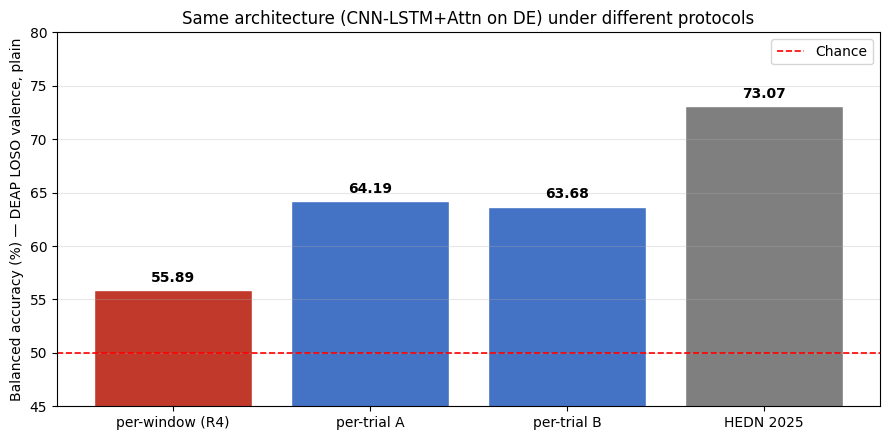

In [19]:
# Focused headline chart — plain valence across protocols
protocols = ['per-window (R4)', 'per-trial A', 'per-trial B', 'HEDN 2025']
val_plain = [
    R4_PERWINDOW[('valence', 'plain')],
    per_fold_all[('A', 'valence', 'plain')]['bal'].mean(),
    per_fold_all[('B', 'valence', 'plain')]['bal'].mean(),
    73.07,
]
colors = ['#c0392b', '#4472C4', '#4472C4', '#7f7f7f']

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(protocols, val_plain, color=colors, edgecolor='white')
ax.axhline(50, color='red', linestyle='--', linewidth=1.2, label='Chance')
for b, v in zip(bars, val_plain):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Balanced accuracy (%) — DEAP LOSO valence, plain')
ax.set_title('Same architecture (CNN-LSTM+Attn on DE) under different protocols')
ax.set_ylim(45, 80)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'protocol_comparison_valence_plain.png', dpi=140, bbox_inches='tight')
plt.show()

## 13. Persist results

In [20]:
for key, df in per_fold_all.items():
    tag = '_'.join(key)
    df.to_csv(RESULTS_DIR / f'per_fold_{tag}.csv', index=False)
for key, cm in cms_all.items():
    tag = '_'.join(key)
    np.save(RESULTS_DIR / f'cm_{tag}.npy', cm)

# Also save the DE arrays for reference
np.save(RESULTS_DIR / 'X_pertrial_methodA.npy', X_A)
np.save(RESULTS_DIR / 'X_pertrial_methodB.npy', X_B)

print('Saved to:', RESULTS_DIR)

Saved to: /content/drive/MyDrive/case_study_2/results/report4b_pertrial
